# Pairs Trading & Statistical Arbitrage
## 05 - Robustness Testing

This notebook tests whether the V/MA pairs trading strategy is robust to changes in its key parameters - the rolling window used to estimate the hedge ratio and z-score, and the entry threshold for initiating a trade. A strategy that only works for one specific parameter set is likely overfit to the historical data. A robust strategy performs reasonably well across a wide range of parameters.

### Parameters Tested
Two key parameters were varied independently:

- **Rolling window:** 63 days (~3 months), 126 days (~6 months), 252 days (~1 year, base case), 504 days (~2 years)
- **Entry threshold:** 1.5, 2.0 (base case), 2.5, and 3.0 standard deviations

Performance was evaluated across all combinations using annualized return, annualized volatility, Sharpe ratio, and max drawdown.

### Base Strategy Results
For the base strategy - cash when the pairs signal is inactive - performance improved monotonically as the window increased and the threshold decreased. The best Sharpe of 0.70 was achieved at 504 days and 1.5 sigma, which sits at the boundary of the parameter space rather than within it. This is a cautionary finding - when results improve consistently toward the edge of the search space it suggests we have not found a true optimum and extending the search further might keep improving results, raising overfitting concerns.

For this reason we do not adopt the boundary parameters. We maintain 252 days and 2.0 sigma as our base case, justified by economic reasoning - one year of data captures a full market cycle for hedge ratio estimation, and two standard deviations represents a meaningful and well documented threshold for statistical dislocation.

### MA Overlay Strategy Results
The picture changes significantly when idle capital is deployed into MA rather than cash. Varying the rolling window with a fixed 2.0 sigma threshold produced a clear interior optimum at 252 days - performance degraded in both directions, with shorter windows producing unstable hedge ratio estimates and longer windows burning through too much data in the warmup period while holding MA without the benefit of the pairs signal.

| Window | Ann. Return | Sharpe | Max Drawdown |
|---|---|---|---|
| 63 days | 11.97% | 0.51 | -52.76% |
| 126 days | 16.79% | 0.75 | -32.99% |
| 252 days | 22.32% | 0.96 | -32.99% |
| 504 days | 18.16% | 0.76 | -48.84% |

The 252 day window is a genuine optimum rather than a boundary result, which gives us confidence the parameter choice is not overfit.

### Limitation - Warmup Period
During the warmup period before the rolling window has enough data, the MA overlay strategy simply holds MA. This introduces a mild lookahead bias - in live trading you would not know in advance that MA would not suffer a catastrophic drawdown during this period. This is a known limitation of the backtest and is most pronounced for longer windows where the warmup period extends to two years.

### Key Takeaway
The base strategy shows boundary-driven improvement that we treat with skepticism. The MA overlay strategy shows a genuine interior optimum at 252 days, consistent with our economic prior and giving us greater confidence in the robustness of the result.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Reload prices
tickers = ["V", "MA"]
raw = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
prices = raw.dropna()

log_returns = np.log(prices / prices.shift(1))

print(f"Loaded: {prices.shape[0]} days")
print(prices.tail())

[*********************100%***********************]  2 of 2 completed

Loaded: 4169 days
Ticker              MA           V
Date                              
2026-07-27  551.710022  362.529999
2026-07-28  562.750000  366.589996
2026-07-29  563.320007  368.730011
2026-07-30  577.349976  366.269989
2026-07-31  573.099976  366.130005


In [3]:
def run_strategy(prices, window=252, entry_threshold=2.0):
    """
    Runs the full pairs trading strategy for given parameters.
    Returns a Series of daily strategy returns.
    
    Parameters:
    - window: rolling window for hedge ratio and z-score (days)
    - entry_threshold: z-score level to enter a trade
    """
    log_returns = np.log(prices / prices.shift(1))
    
    rolling_beta = pd.Series(index=prices.index, dtype=float)
    rolling_alpha = pd.Series(index=prices.index, dtype=float)
    
    for i in range(window, len(prices)):
        window_prices = prices.iloc[i-window:i]
        X = add_constant(window_prices["V"])
        y = window_prices["MA"]
        model = OLS(y, X).fit()
        rolling_beta.iloc[i] = model.params["V"]
        rolling_alpha.iloc[i] = model.params["const"]
    
    spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    zscore = (spread - rolling_mean) / rolling_std
    
    signals = pd.Series(0.0, index=zscore.index)
    position = 0
    
    for i in range(len(zscore)):
        z = zscore.iloc[i]
        if np.isnan(z):
            signals.iloc[i] = 0
            continue
        if position == 0:
            if z < -entry_threshold:
                position = 1
            elif z > entry_threshold:
                position = -1
        elif position == 1:
            if z >= 0:
                position = 0
        elif position == -1:
            if z <= 0:
                position = 0
        signals.iloc[i] = position
    
    # Returns
    strategy_returns = (
        signals.shift(1) * log_returns["MA"] -
        signals.shift(1) * log_returns["V"]
    ).dropna()
    
    return strategy_returns

def performance_summary(returns, label):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    cumulative = returns.cumsum()
    drawdown = cumulative - cumulative.cummax()
    max_dd = drawdown.min()
    print(f"\n{label}")
    print(f"  Ann. Return: {ann_return:.2%}  Vol: {ann_vol:.2%}  Sharpe: {sharpe:.2f}  Max DD: {max_dd:.2%}")

In [4]:
# Test different rolling windows
# 126 days ~ 6 months
# 252 days ~ 1 year (base case)
# 504 days ~ 2 years

windows = [63, 126, 252, 504]

print("=" * 55)
print("ROLLING WINDOW SENSITIVITY")
print("=" * 55)

window_results = {}
for w in windows:
    returns = run_strategy(prices, window=w, entry_threshold=2.0)
    window_results[w] = returns
    label = f"Window = {w} days (~{w//21} months)"
    performance_summary(returns, label)

ROLLING WINDOW SENSITIVITY

Window = 63 days (~3 months)
  Ann. Return: 2.24%  Vol: 8.77%  Sharpe: 0.26  Max DD: -18.55%

Window = 126 days (~6 months)
  Ann. Return: 2.89%  Vol: 8.85%  Sharpe: 0.33  Max DD: -13.49%

Window = 252 days (~12 months)
  Ann. Return: 3.48%  Vol: 7.78%  Sharpe: 0.45  Max DD: -12.67%

Window = 504 days (~24 months)
  Ann. Return: 3.93%  Vol: 6.80%  Sharpe: 0.58  Max DD: -8.40%


In [5]:
# Test different entry thresholds

thresholds = [1.5, 2.0, 2.5, 3.0]

print("=" * 55)
print("ENTRY THRESHOLD SENSITIVITY")
print("=" * 55)

threshold_results = {}
for t in thresholds:
    returns = run_strategy(prices, window=252, entry_threshold=t)
    threshold_results[t] = returns
    label = f"Threshold = {t} sigma"
    performance_summary(returns, label)

ENTRY THRESHOLD SENSITIVITY

Threshold = 1.5 sigma
  Ann. Return: 5.50%  Vol: 8.68%  Sharpe: 0.63  Max DD: -12.67%

Threshold = 2.0 sigma
  Ann. Return: 3.48%  Vol: 7.78%  Sharpe: 0.45  Max DD: -12.67%

Threshold = 2.5 sigma
  Ann. Return: 2.35%  Vol: 6.62%  Sharpe: 0.36  Max DD: -12.67%

Threshold = 3.0 sigma
  Ann. Return: 2.00%  Vol: 6.07%  Sharpe: 0.33  Max DD: -12.67%


Running parameter grid - this may take a minute...

Sharpe Ratio Heatmap:
      1.5   2.0   2.5   3.0
63   0.42  0.26  0.17 -0.02
126  0.52  0.33  0.49  0.47
252  0.63  0.45  0.36  0.33
504  0.70  0.58  0.55  0.47


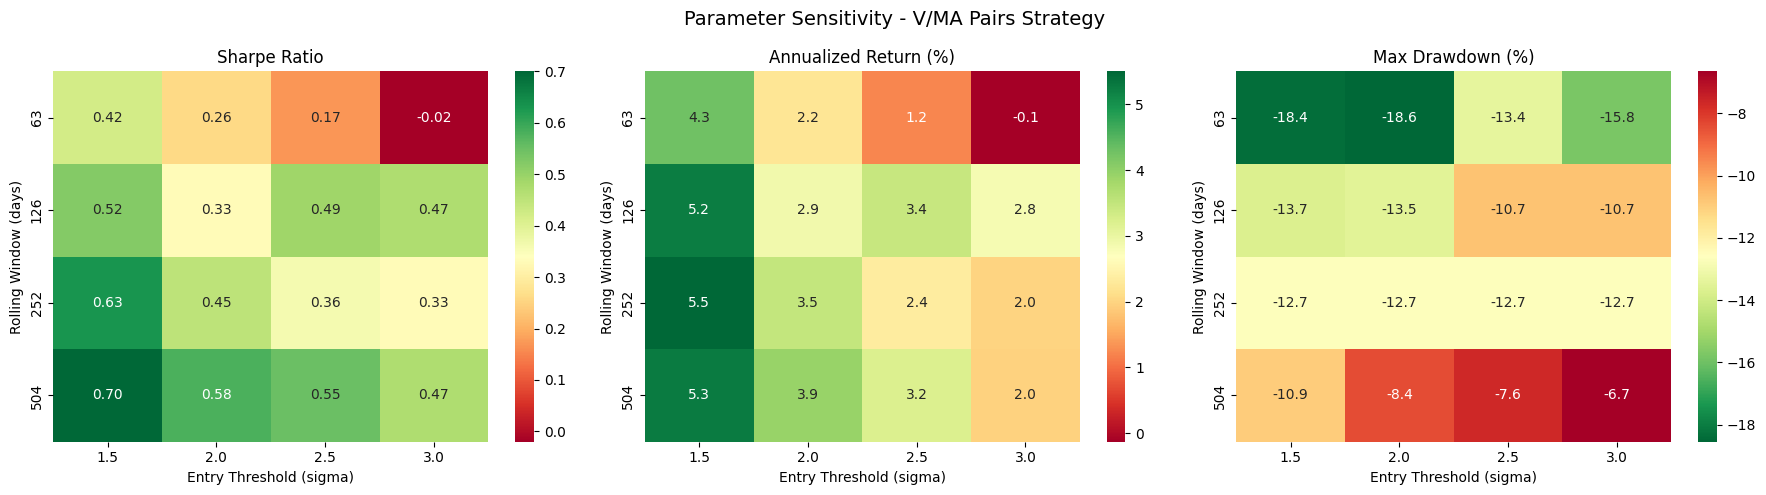

In [6]:
# Full parameter grid - Sharpe ratio heatmap
windows = [63, 126, 252, 504]
thresholds = [1.5, 2.0, 2.5, 3.0]

sharpe_matrix = pd.DataFrame(index=windows, columns=thresholds, dtype=float)
return_matrix = pd.DataFrame(index=windows, columns=thresholds, dtype=float)
drawdown_matrix = pd.DataFrame(index=windows, columns=thresholds, dtype=float)

print("Running parameter grid - this may take a minute...")

for w in windows:
    for t in thresholds:
        returns = run_strategy(prices, window=w, entry_threshold=t)
        ann_return = returns.mean() * 252
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol
        cumulative = returns.cumsum()
        max_dd = (cumulative - cumulative.cummax()).min()
        sharpe_matrix.loc[w, t] = round(sharpe, 2)
        return_matrix.loc[w, t] = round(ann_return, 4)
        drawdown_matrix.loc[w, t] = round(max_dd, 4)

print("\nSharpe Ratio Heatmap:")
print(sharpe_matrix)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(sharpe_matrix.astype(float), annot=True, fmt=".2f", 
            cmap="RdYlGn", ax=axes[0], cbar=True)
axes[0].set_title("Sharpe Ratio", fontsize=12)
axes[0].set_xlabel("Entry Threshold (sigma)")
axes[0].set_ylabel("Rolling Window (days)")

sns.heatmap(return_matrix.astype(float) * 100, annot=True, fmt=".1f",
            cmap="RdYlGn", ax=axes[1], cbar=True)
axes[1].set_title("Annualized Return (%)", fontsize=12)
axes[1].set_xlabel("Entry Threshold (sigma)")
axes[1].set_ylabel("Rolling Window (days)")

sns.heatmap(drawdown_matrix.astype(float) * 100, annot=True, fmt=".1f",
            cmap="RdYlGn_r", ax=axes[2], cbar=True)
axes[2].set_title("Max Drawdown (%)", fontsize=12)
axes[2].set_xlabel("Entry Threshold (sigma)")
axes[2].set_ylabel("Rolling Window (days)")

plt.suptitle("Parameter Sensitivity - V/MA Pairs Strategy", fontsize=14)
plt.tight_layout()
plt.show()

Running window sensitivity with MA overlay...


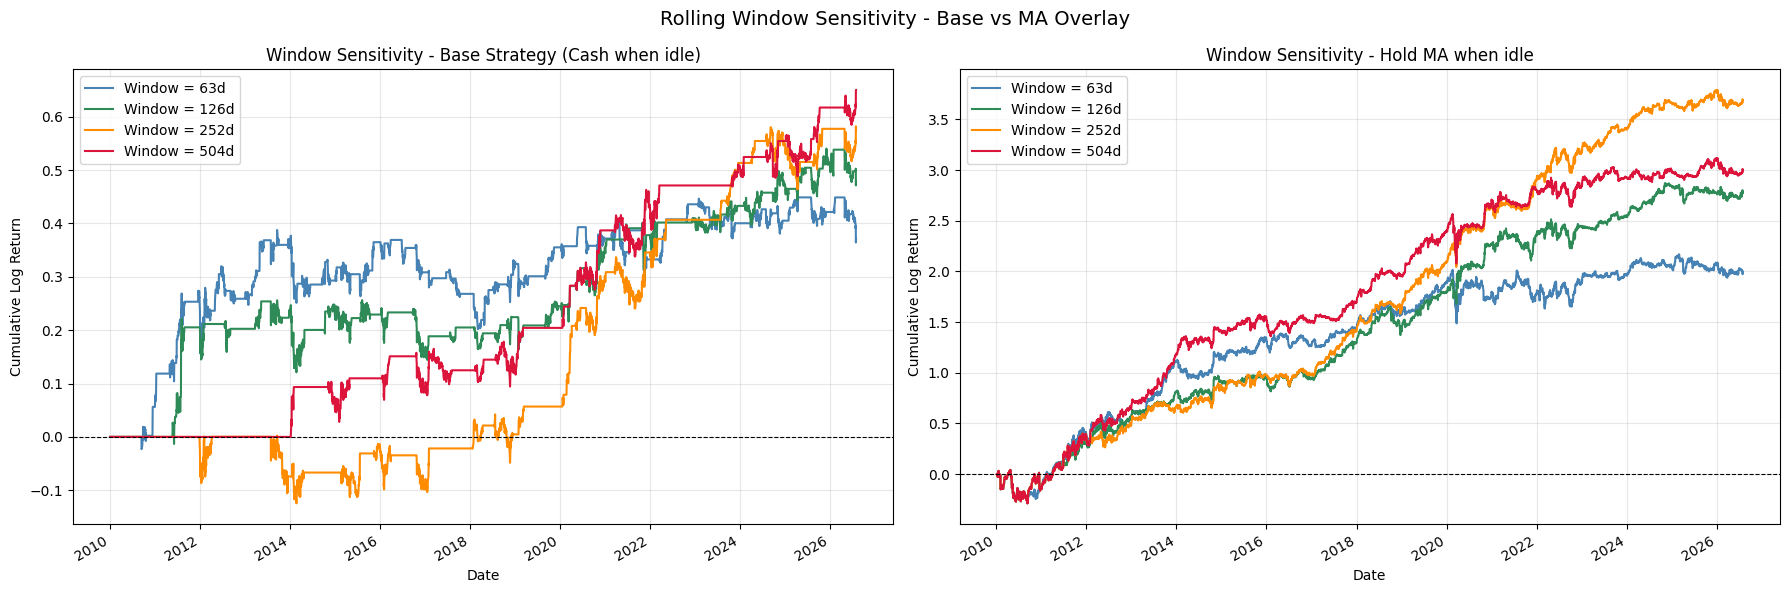


WINDOW SENSITIVITY - BASE STRATEGY

Window = 63 days
  Ann. Return: 2.24%  Vol: 8.77%  Sharpe: 0.26  Max DD: -18.55%

Window = 126 days
  Ann. Return: 2.89%  Vol: 8.85%  Sharpe: 0.33  Max DD: -13.49%

Window = 252 days
  Ann. Return: 3.48%  Vol: 7.78%  Sharpe: 0.45  Max DD: -12.67%

Window = 504 days
  Ann. Return: 3.93%  Vol: 6.80%  Sharpe: 0.58  Max DD: -8.40%

WINDOW SENSITIVITY - MA OVERLAY

Window = 63 days
  Ann. Return: 11.97%  Vol: 23.58%  Sharpe: 0.51  Max DD: -52.76%

Window = 126 days
  Ann. Return: 16.79%  Vol: 22.53%  Sharpe: 0.75  Max DD: -32.99%

Window = 252 days
  Ann. Return: 22.32%  Vol: 23.36%  Sharpe: 0.96  Max DD: -32.99%

Window = 504 days
  Ann. Return: 18.16%  Vol: 23.86%  Sharpe: 0.76  Max DD: -48.84%


In [7]:
# Reload MA returns for overlay
ma_returns = np.log(prices["MA"] / prices["MA"].shift(1))

def run_strategy_with_ma(prices, window=252, entry_threshold=2.0):
    """
    Same as run_strategy but holds MA during idle periods.
    """
    log_returns = np.log(prices / prices.shift(1))
    
    rolling_beta = pd.Series(index=prices.index, dtype=float)
    rolling_alpha = pd.Series(index=prices.index, dtype=float)
    
    for i in range(window, len(prices)):
        window_prices = prices.iloc[i-window:i]
        X = add_constant(window_prices["V"])
        y = window_prices["MA"]
        model = OLS(y, X).fit()
        rolling_beta.iloc[i] = model.params["V"]
        rolling_alpha.iloc[i] = model.params["const"]
    
    spread = prices["MA"] - (rolling_alpha + rolling_beta * prices["V"])
    rolling_mean = spread.rolling(window=window).mean()
    rolling_std = spread.rolling(window=window).std()
    zscore = (spread - rolling_mean) / rolling_std
    
    signals = pd.Series(0.0, index=zscore.index)
    position = 0
    
    for i in range(len(zscore)):
        z = zscore.iloc[i]
        if np.isnan(z):
            signals.iloc[i] = 0
            continue
        if position == 0:
            if z < -entry_threshold:
                position = 1
            elif z > entry_threshold:
                position = -1
        elif position == 1:
            if z >= 0:
                position = 0
        elif position == -1:
            if z <= 0:
                position = 0
        signals.iloc[i] = position
    
    # Hold MA when no signal
    strategy_returns = pd.Series(index=prices.index, dtype=float)
    for date in prices.index:
        if signals.shift(1).loc[date] != 0:
            strategy_returns.loc[date] = (
                signals.shift(1).loc[date] * log_returns.loc[date, "MA"] -
                signals.shift(1).loc[date] * log_returns.loc[date, "V"]
            )
        else:
            strategy_returns.loc[date] = log_returns.loc[date, "MA"]
    
    return strategy_returns.dropna()

print("Running window sensitivity with MA overlay...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

colors = ["steelblue", "seagreen", "darkorange", "crimson"]

# Base strategy - cash when idle
for w, color in zip(windows, colors):
    returns = run_strategy(prices, window=w, entry_threshold=2.0)
    returns.cumsum().plot(ax=ax1, label=f"Window = {w}d", color=color, linewidth=1.5)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Window Sensitivity - Base Strategy (Cash when idle)", fontsize=12)
ax1.set_ylabel("Cumulative Log Return")
ax1.legend()
ax1.grid(alpha=0.3)

# MA overlay - hold MA when idle
for w, color in zip(windows, colors):
    returns = run_strategy_with_ma(prices, window=w, entry_threshold=2.0)
    returns.cumsum().plot(ax=ax2, label=f"Window = {w}d", color=color, linewidth=1.5)

ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Window Sensitivity - Hold MA when idle", fontsize=12)
ax2.set_ylabel("Cumulative Log Return")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("Rolling Window Sensitivity - Base vs MA Overlay", fontsize=14)
plt.tight_layout()
plt.show()

# Performance comparison
print("\n" + "=" * 55)
print("WINDOW SENSITIVITY - BASE STRATEGY")
print("=" * 55)
for w in windows:
    returns = run_strategy(prices, window=w, entry_threshold=2.0)
    performance_summary(returns, f"Window = {w} days")

print("\n" + "=" * 55)
print("WINDOW SENSITIVITY - MA OVERLAY")
print("=" * 55)
for w in windows:
    returns = run_strategy_with_ma(prices, window=w, entry_threshold=2.0)
    performance_summary(returns, f"Window = {w} days")